In [10]:
# Note: 
# 1. You need to be connected to the HKU network or HKU VPN to access the chenlin04 server.
# 2. Do not upload chenlin04_student_login.txt to any public repository, such as GitHub and LLMs.
# 3. Contact Boao (boaozhan@connect.hku.hk) for any questions related to accessing/using the LinkUp data.

## Imports

In [11]:
import pandas as pd
import requests
import clickhouse_connect
from collections import namedtuple
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt

## DB Connection

In [12]:
class SimpleResult:
    def __init__(self, json_data):
        self.result_rows = json_data.get('data', [])
        self.column_names = [meta['name'] for meta in json_data.get('meta', [])]

class SimpleClient:
    def __init__(self, host, username, password, **kwargs):
        self.base_url = f"http://{host}:8123/"
        self.auth = {
            'user': username,
            'password': password
        }
        
    def query(self, query_string):
        params = self.auth.copy()
        # Use JSON format to get metadata (column names) easily
        params['query'] = query_string + " FORMAT JSON"
        
        response = requests.get(self.base_url, params=params)
        
        if response.status_code != 200:
            raise Exception(f"Query failed: {response.text}")
            
        return SimpleResult(response.json())

# Initialize the client
with open('chenlin04_student_login.txt', 'r') as f:
    conn_info = eval(f.read())
    try:
        # Try to connect with clickhouse first
        client = clickhouse_connect.get_client(**conn_info)
        print("Connected using standard clickhouse_connect")
    except Exception as e:
        # If it doesn't work out, use requests
        print(f"Standard connection failed: {e}")
        print("Falling back to SimpleClient (lightweight mode)...")
        client = SimpleClient(**conn_info)
        print("Connected using SimpleClient")

Connected using standard clickhouse_connect


## Helper functions

In [74]:
def read_sql(sql: str) -> pd.DataFrame:
    """
    Executes an SQL query through the configured client and returns the results as a pandas DataFrame.
    
    Parameters:
        sql (str): The SQL query string to be executed.
    
    Returns:
        pd.DataFrame: The resulting data returned by the query as a DataFrame. 
                      If the query fails or cannot be loaded, returns an empty DataFrame.
    """
    if client is None:
        raise ValueError("Client is not initialized. Please call connect to the database first.")
    res = client.query(sql)
    try:
        return pd.DataFrame(res.result_rows, columns=res.column_names)
    except Exception as e:
        print('Failed to read the result into a dataframe')
        return pd.DataFrame()

In [75]:
def get_cusip(company_id: int) -> str:
    sql = f"""
    select cusip from fina4359_linkup_202603.company_id_compustat_identifiers
    where company_id = {company_id}
    """
    cusip = read_sql(sql)['cusip'].values[0][:-1]
    return cusip
def get_daily_ret(company_id: int) -> pd.DataFrame:
    cusip = get_cusip(company_id)
    sql = f"""
    select * from fina4359_linkup_202603.crsp_daily_ret_all_firms_since_2000
    where CUSIP = '{cusip}'
    """
    daily_ret = read_sql(sql)
    daily_ret['company_id'] = company_id
    daily_ret['ts'] = pd.to_datetime(daily_ret['date'],format='%Y%m%d')
    daily_ret['RET'] = daily_ret['RET'].astype(float)
    daily_ret['RETX'] = daily_ret['RETX'].astype(float)
    return daily_ret

In [76]:
def get_hash_series(company_id: int) -> pd.DataFrame:
    """
    Get the daily series of job posting hashes for a given company, where each row represents a snapshot
    of a job posting (identified by its hash) on each day it was active (from 'created' to 'last_seen').
    This function creates a time series of job posting lifespans, effectively producing a daily snapshot
    of all active job posts for the company.

    Each hash represents a unique job posting. By generating this daily hash series, you obtain a panel
    or 'snapshot' dataset that shows, for each day, which postings are active. This can be used to map
    or join (by hash) any job-level attributes (such as location, job title, etc.) to produce a detailed
    snapshot of posting characteristics for each day in the company's history.

    Input:
        company_id (int): The unique identifier of the company (maps to the database table for the firm).

    Output:
        pd.DataFrame: DataFrame containing columns:
            - company_id (int): The input company_id, repeated for each row.
            - ts (pd.Timestamp): Each date in the hash's valid interval (from created to last_seen).
            - hash (str): The unique hash identifier for the job posting active on that date.

    The output has one row for each (company_id, ts, hash) combination, where ts is each day in the
    job posting's (hash) live interval, according to the posting table. Use the hash column to map
    attributes from other job-level tables, enabling per-day job posting attribute snapshots.
    """
    sql = f"""
    select hash, created, last_seen 
    from fina4359_linkup_202603.firm_{company_id}
    """
    hash_tbl = read_sql(sql)
    hash_tbl['created'] = pd.to_datetime(hash_tbl['created'], format='%Y-%m-%d')
    hash_tbl['last_seen'] = pd.to_datetime(hash_tbl['last_seen'], format='%Y-%m-%d')
    hash_tbl['hash'] = hash_tbl['hash'].astype(str)

    # Determine the overall span of hash posting dates for the company.
    start_date = hash_tbl['created'].min()
    end_date = hash_tbl['last_seen'].max()
    snapshot_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    snapshots = []

    # For each date in the posting span, find all job postings ("hash") active that day.
    for date in tqdm(snapshot_dates, desc="Creating snapshot of active job postings"):
        active_jobs = hash_tbl[(date >= hash_tbl['created']) & (date <= hash_tbl['last_seen'])].copy()
        if not active_jobs.empty:
            active_jobs['ts'] = date
            snapshots.append(active_jobs)

    if snapshots:
        hash_series = pd.concat(snapshots).sort_values(by='ts').reset_index(drop=True)
        hash_series['company_id'] = company_id
        hash_series = hash_series[['company_id', 'ts', 'hash']]
    else:
        # Return empty DataFrame with correct columns if no postings are found.
        hash_series = pd.DataFrame(columns=['company_id', 'ts', 'hash'])

    return hash_series

In [77]:
def get_job_attr(
    company_id: int,
) -> pd.DataFrame:
    """
    Retrieve all job attribute columns (except job description) for the given company_id
    from the LinkUp firm-specific table. The hash column serves as the unique job posting
    identifier, which can be mapped to the hash series to create job snapshots over time.

    Parameters
    ----------
    company_id : int
        The unique identifier for the target company (corresponds to the firm N in table fina4359_linkup_202603.firm_<N>).

    Returns
    -------
    pd.DataFrame
        DataFrame with one row for each job posting for that company, containing all attributes except the 'description' field.
        Columns:
            - hash: str, unique job posting identifier
            - onet: occupation code (float or object)
            - country: int code for country
            - state: int code for state
            - zip: zip code (can be float if missing values)
            - created: datetime, posting creation date
            - last_updated: datetime, last updated date (can be NaT)
            - updates: int, counter of update events
            - last_seen: datetime, last job seen date
            - missing: datetime, first date posting is marked "missing" (can be NaT)

    Notes
    -----
    This extraction is complementary to the job description retrieval (see get_job_des).
    'hash' can be used as a key to join to hash-series snapshots.
    """
    sql = f"""
        select hash, onet, country, state, zip, created, last_updated, updates, last_seen, missing 
        from fina4359_linkup_202603.firm_{company_id}
    """
    attr_tbl = read_sql(sql)
    attr_tbl['onet'] = attr_tbl['onet'].fillna(-1).astype(int).astype(str).replace(-1,pd.NA)
    attr_tbl['country'] = attr_tbl['country'].fillna(-1).astype(int).astype(str).replace(-1,pd.NA)
    attr_tbl['state'] = attr_tbl['state'].fillna(-1).astype(int).astype(str).replace(-1,pd.NA)
    attr_tbl['created'] = pd.to_datetime(attr_tbl['created'], format='%Y-%m-%d')
    attr_tbl['missing'] = pd.to_datetime(attr_tbl['missing'], format='%Y-%m-%d')
    attr_tbl['hash'] = attr_tbl['hash'].astype(str)
    attr_tbl['last_updated'] = pd.to_datetime(attr_tbl['last_updated'], format='%Y-%m-%d')
    attr_tbl['last_seen'] = pd.to_datetime(attr_tbl['last_seen'], format='%Y-%m-%d')
    return attr_tbl

In [78]:
def get_job_des(
    company_id: int,
) -> pd.DataFrame:
    """
    Retrieve job descriptions for all postings associated with the specified company_id
    from the LinkUp firm-specific table.

    Parameters
    ----------
    company_id : int
        The unique identifier for the target company (corresponds to the firm N in table fina4359_linkup_202603.firm_<N>).

    Returns
    -------
    pd.DataFrame
        DataFrame with one row per job posting for that company, containing:
            - hash: str, unique job posting identifier
            - description: str, raw job description text (with normalized newlines)
    
    Notes
    -----
    This function provides only the job description text (and posting hash) and is complementary to other job attribute retrieval.
    The hash column can be used to join with other firm/job-attribute tables.
    """
    sql = f"""
        select hash, description from fina4359_linkup_202603.firm_{company_id}
    """
    des_tbl = read_sql(sql)
    des_tbl['hash'] = des_tbl['hash'].astype(str)
    des_tbl['description'] = des_tbl['description'].str.replace("\\n", "\n")
    return des_tbl

In [79]:
def plot_feat_by_ts(feat: pd.DataFrame):
    # Assuming index is MultiIndex (company_id, ts), drop company_id to plot aggregated over all companies
    feat_by_ts = feat.reset_index(level='company_id', drop=True)

    fig, axs = plt.subplots(len(feat_by_ts.columns), 1, figsize=(15, 3*len(feat_by_ts.columns)), sharex=True)
    if len(feat_by_ts.columns) == 1:
        axs = [axs]

    for i, col in enumerate(feat_by_ts.columns):
        axs[i].plot(feat_by_ts.index, feat_by_ts[col])
        axs[i].set_ylabel(col)
        axs[i].set_title(col)
    plt.xlabel('ts')
    plt.tight_layout()
    plt.show()

## EDA

### Data descriptions

In [19]:
all_tbls = read_sql("show tables from fina4359_linkup_202603")
all_tbls.head(5)

,name
0,company_id_compustat_identifiers
1,compustat_na_quarterly_all_firms_since_2000
2,country_state_code_mapping
3,crsp_daily_ret_all_firms_since_2000
4,crsp_monthly_ret_all_firms_since_2000


In [43]:
daily_ret = read_sql(
    """
    select * from fina4359_linkup_202603.crsp_daily_ret_all_firms_since_2000 
    where date >= 20100101
    order by CUSIP desc limit 100
    """
)
daily_ret.head(5)

,PERMNO,date,TICKER,COMNAM,PERMCO,CUSIP,DIVAMT,PRC,VOL,RET,OPENPRC,RETX
0,15857,20200609,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,10.04,320486.0,-0.005941,10.08,-0.005941
1,15857,20180223,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,50.75,122276.0,0.002964,51.00,0.002964
2,15857,20220916,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,3.22,813390.0,-0.041667,3.36,-0.041667
3,15857,20220915,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,3.36,129291.0,-0.045455,3.49,-0.045455
4,15857,20241226,WVE,W A V E LIFE SCIENCES LTD,55491,Y9530810,None,13.48,418580.0,0.005220,13.26,0.005220


In [21]:
reg_mapping = read_sql("select * from fina4359_linkup_202603.country_state_code_mapping")
reg_mapping.head(5)

,country,state,country_name,state_name
0,0,0,None,None
1,0,1,None,CA
2,0,2,None,TX
3,0,3,None,FL
4,0,4,None,VA


In [22]:
id_mapping = read_sql("select * from fina4359_linkup_202603.company_id_compustat_identifiers")
id_mapping.head(5)

,company_id,cusip,gvkey,tic,conm,naics
0,20238,898402102,4685,TRMK,TRUSTMARK CORP,522110.0
1,43730,881569107,170969,TSRO,TESARO INC,325414.0
2,44223,539830109,6774,LMT,LOCKHEED MARTIN CORP,336414.0
3,12903,10948C107,33637,BV,BRIGHTVIEW HOLDINGS,541320.0
4,17378,38268T103,20644,GPRO,GOPRO INC,333316.0


In [23]:
sample_tbl = read_sql("select * from fina4359_linkup_202603.firm_10467 limit 100")
sample_tbl.head(5)

,hash,onet,country,state,zip,created,last_updated,updates,last_seen,missing,description
0,0489e44cfda10132c1061d8aeff1692d,15119909.0,1,24,97228.0,2016-10-08,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
1,094b60f6a344771862769e2570220e28,41203100.0,1,20,55122.0,2016-09-02,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
2,0c5fffb23fcf90bdb359d6f2046f0806,41203100.0,1,2,77429.0,2017-01-06,None,0,2017-01-29,2017-02-01,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
3,0a28eddba451425b131ff6d0413035f2,41203100.0,1,2,77502.0,2016-09-02,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
4,0b4fabe2406bdd38698a8c60a3e0e64d,27202100.0,1,4,10601.0,2016-10-04,None,0,2017-02-03,2017-02-05,Work Hard. Play Hard.


In [62]:
def get_cusip(company_id: int) -> str:
    sql = f"""
    select cusip from fina4359_linkup_202603.company_id_compustat_identifiers
    where company_id = {company_id}
    """
    return int(read_sql(sql)['cusip'].values[0][:-1])
def get_daily_ret(company_id: int) -> pd.DataFrame:
    cusip = get_cusip(company_id)
    sql = f"""
    select * from fina4359_linkup_202603.crsp_daily_ret_all_firms_since_2000
    where CUSIP = '{cusip}'
    """
    return read_sql(sql)

### Config

In [82]:
company_id = 10467

### Return

In [90]:
daily_ret = get_daily_ret(company_id)
daily_ret = daily_ret.set_index(['company_id','ts'])
daily_ret.head(5)

PERMNO      date TICKER    COMNAM  PERMCO     CUSIP  \
company_id ts                                                                
10467      2000-01-03   57665  20000103    NKE  NIKE INC    3194  65410610   
           2000-01-04   57665  20000104    NKE  NIKE INC    3194  65410610   
           2000-01-05   57665  20000105    NKE  NIKE INC    3194  65410610   
           2000-01-06   57665  20000106    NKE  NIKE INC    3194  65410610   
           2000-01-07   57665  20000107    NKE  NIKE INC    3194  65410610   

                       DIVAMT     PRC        VOL       RET  OPENPRC      RETX  
company_id ts                                                                  
10467      2000-01-03     NaN  48.125  1001800.0 -0.029004  49.3125 -0.029004  
           2000-01-04     NaN  45.500  1226299.0 -0.054545  47.0000 -0.054545  
           2000-01-05     NaN  48.125   817800.0  0.057692  45.7500  0.057692  
           2000-01-06     NaN  47.875   611400.0 -0.005195  47.8750 -0.005195  
           2000-01-07     NaN  47.875   499200.0  0.000000  47.6875  0.000000

### Feature

In [84]:
# This creates a time series of active job postings
hash = get_hash_series(company_id)

Creating snapshot of active job postings: 100%|██████████| 3238/3238 [00:03<00:00, 990.91it/s] 


In [85]:
# Can merge to hash to get the attributes of active job postings on each day
# can be slow and memory-intensive, especially for description
attr = get_job_attr(company_id) # attributes except description
des = get_job_des(company_id) # description

In [86]:
hash_attr = hash.merge(attr,on='hash',how='left')
hash_attr['lasting'] = (hash_attr['ts'] - hash_attr['created'])/timedelta(days=1)
hash_attr['region'] = hash_attr['country'].astype(str) + '_' + hash_attr['state'].astype(str)
hash_attr['onet_group'] = hash_attr['onet'].astype(str).str[:2]
hash_attr['onet_occupation'] = hash_attr['onet'].astype(str).str[2:6]
hash_attr['onet_specific'] = hash_attr['onet'].astype(str).str[6:]
hash_attr.head(5)

,company_id,ts,hash,onet,country,state,zip,created,last_updated,updates,last_seen,missing,lasting,region,onet_group,onet_occupation,onet_specific
0,10467,2013-11-18,5fe5a26277e7689e98dc87a82cfba50c,15113200,1,24,97228.0,2013-11-18,NaT,0,2014-09-02,2014-09-05,0.0,1_24,15,1132,00
1,10467,2013-11-19,5fe5a26277e7689e98dc87a82cfba50c,15113200,1,24,97228.0,2013-11-18,NaT,0,2014-09-02,2014-09-05,1.0,1_24,15,1132,00
2,10467,2013-11-20,5fe5a26277e7689e98dc87a82cfba50c,15113200,1,24,97228.0,2013-11-18,NaT,0,2014-09-02,2014-09-05,2.0,1_24,15,1132,00
3,10467,2013-11-21,5fe5a26277e7689e98dc87a82cfba50c,15113200,1,24,97228.0,2013-11-18,NaT,0,2014-09-02,2014-09-05,3.0,1_24,15,1132,00
4,10467,2013-11-22,0384eb1eb529ff96a28f836918398695,41203100,1,20,55301.0,2013-11-22,NaT,0,2014-06-17,2014-06-19,0.0,1_20,41,2031,00


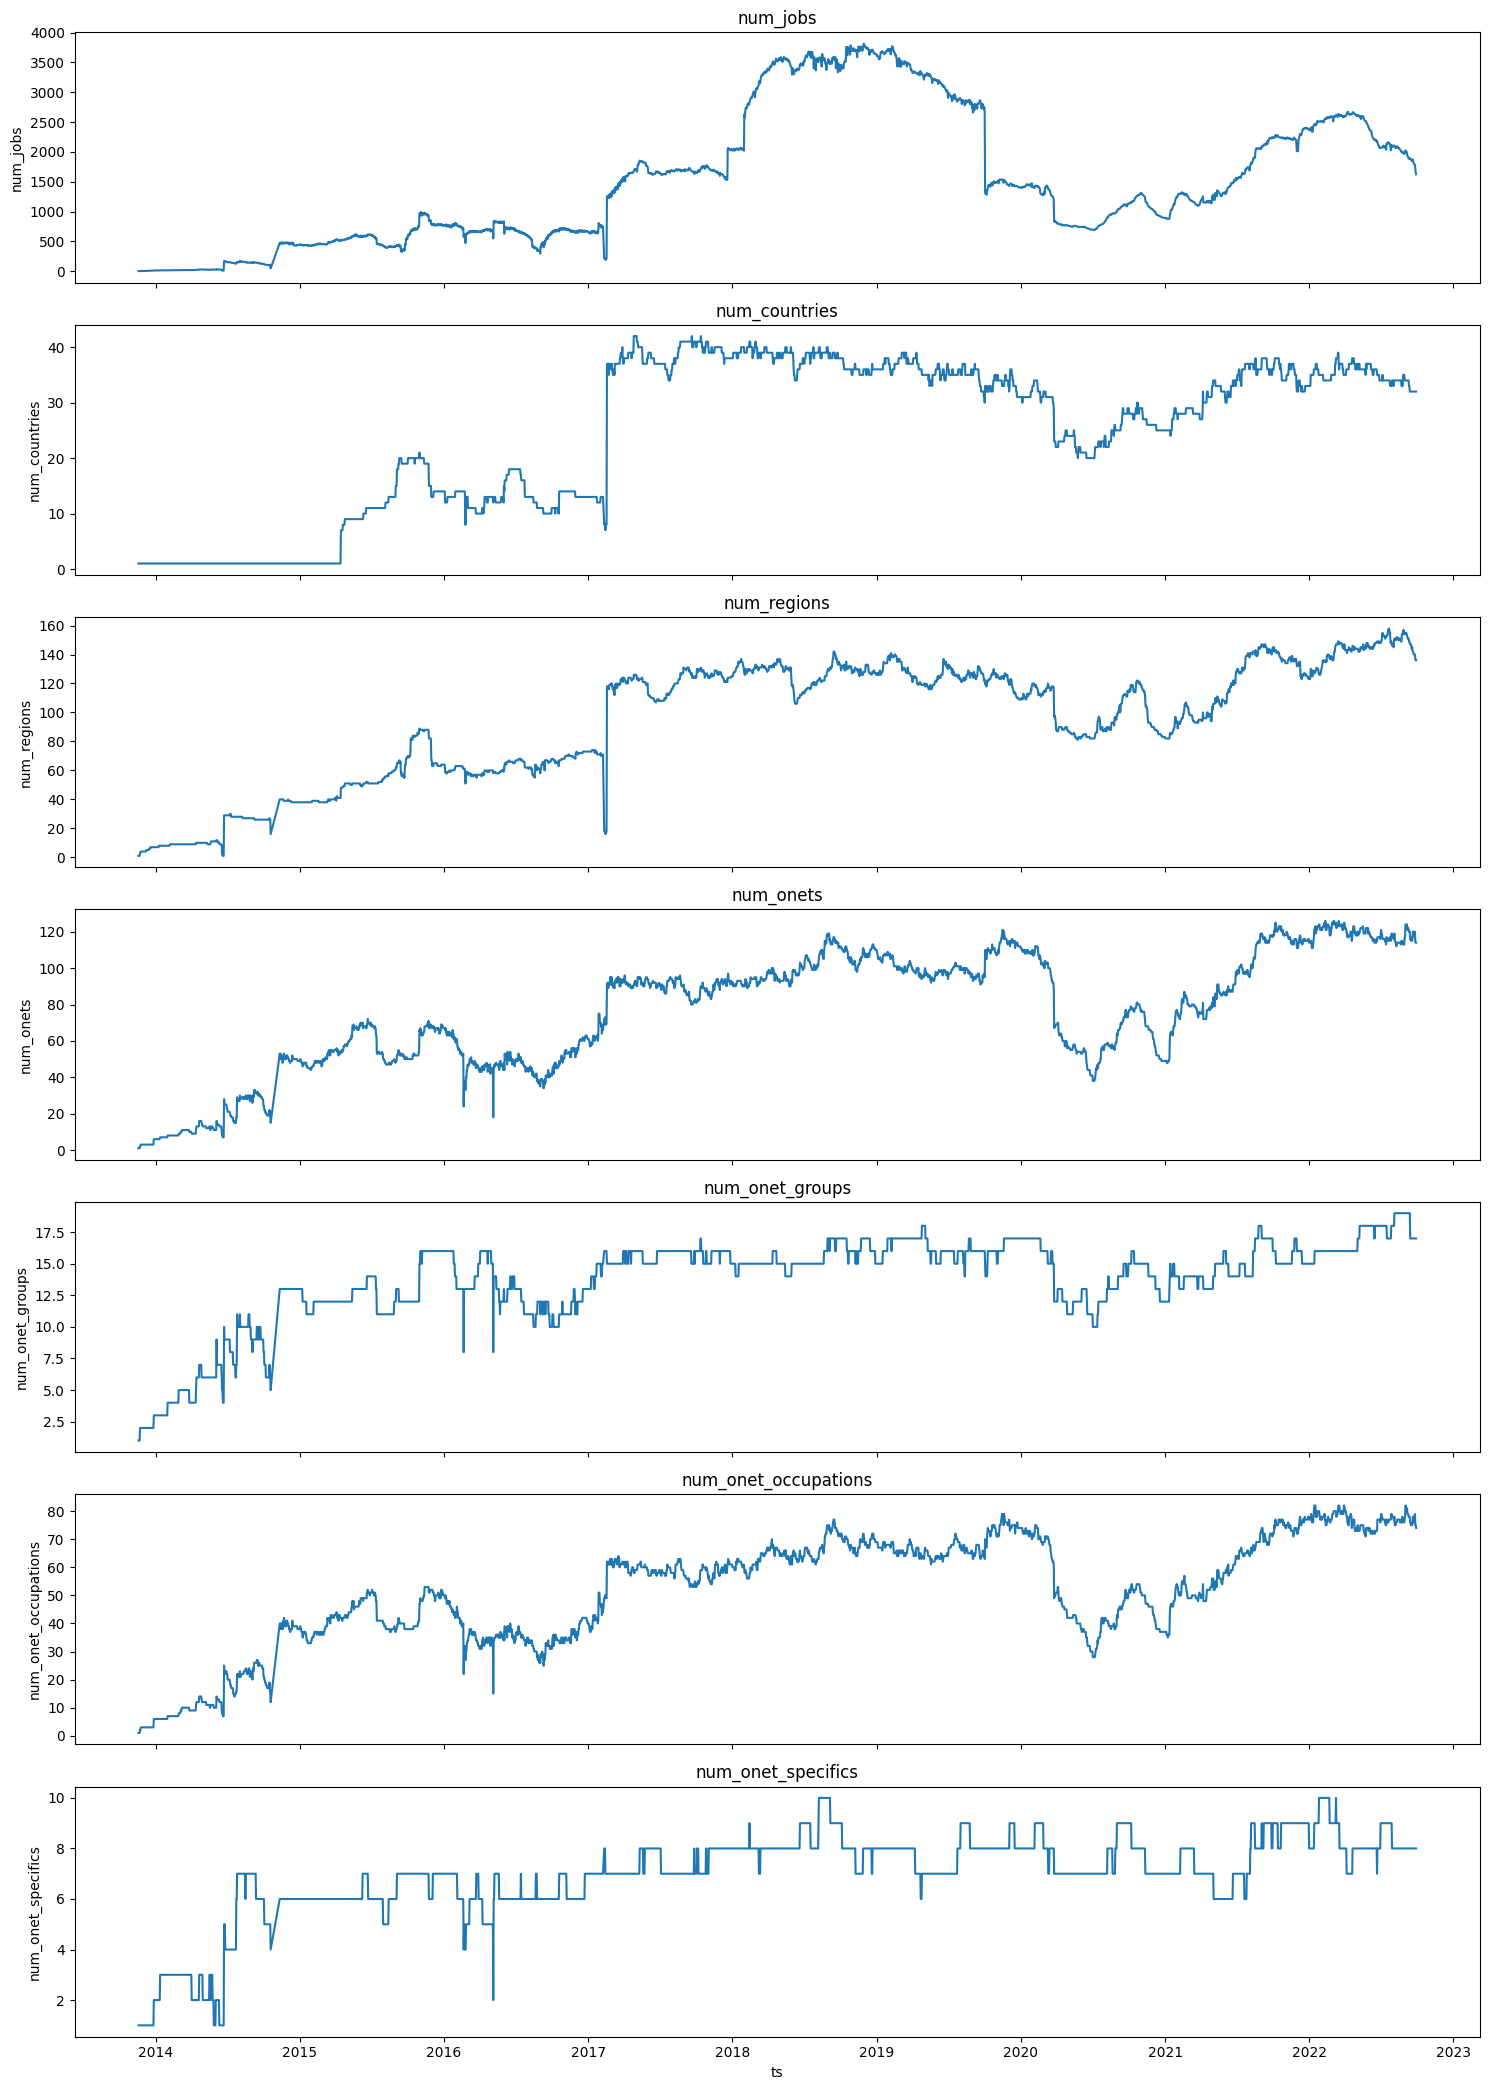

In [92]:
feat = hash_attr.groupby(['company_id','ts']).agg(
    num_jobs = ('hash','nunique'),
    num_countries = ('country','nunique'),
    num_regions = ('region','nunique'),
    num_onets = ('onet','nunique'),
    num_onet_groups = ('onet_group','nunique'),
    num_onet_occupations = ('onet_occupation','nunique'),
    num_onet_specifics = ('onet_specific','nunique'),
    #min_lasting = ('lasting','min'),
    #max_lasting = ('lasting','max'),
    #med_lasting = ('lasting','median'),
    #std_lasting = ('lasting','std'),
)
plot_feat_by_ts(feat)

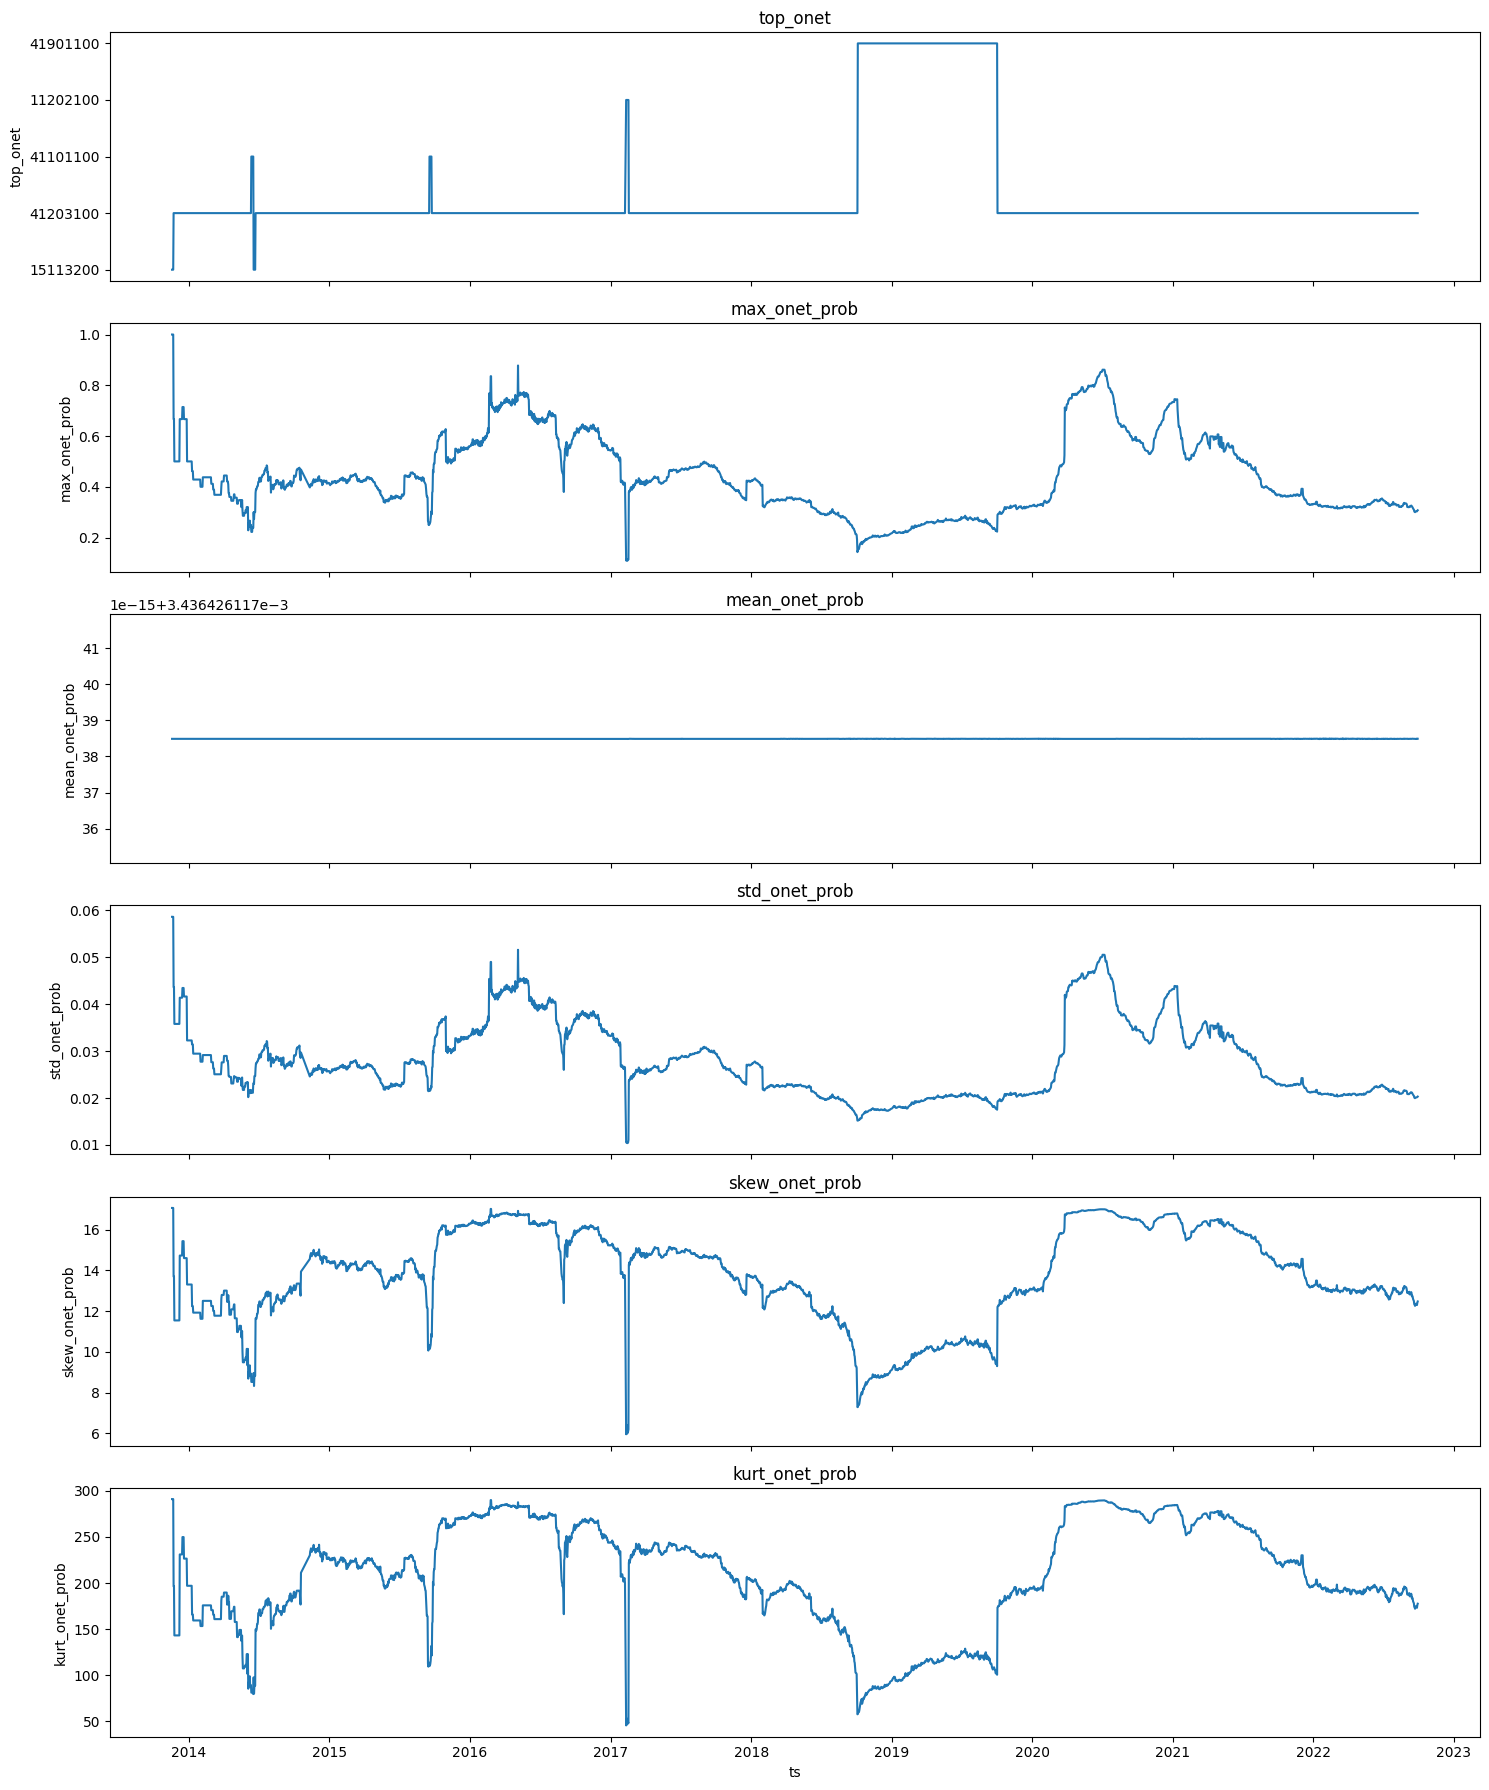

In [93]:
onet_pivot = hash_attr.pivot_table(
    index=['company_id','ts'],
    columns='onet',
    values='hash',
    aggfunc='nunique',
    fill_value=0,
)
# normalize to get the probability of each occupation on each day
onet_pivot = onet_pivot.div(onet_pivot.sum(axis=1),axis=0)
onet_dist = pd.DataFrame({
    'top_onet': onet_pivot.idxmax(axis=1),
    'max_onet_prob': onet_pivot.max(axis=1),
    'mean_onet_prob': onet_pivot.mean(axis=1),
    'std_onet_prob': onet_pivot.std(axis=1),
    'skew_onet_prob': onet_pivot.skew(axis=1),
    'kurt_onet_prob': onet_pivot.kurt(axis=1),
})
plot_feat_by_ts(onet_dist)

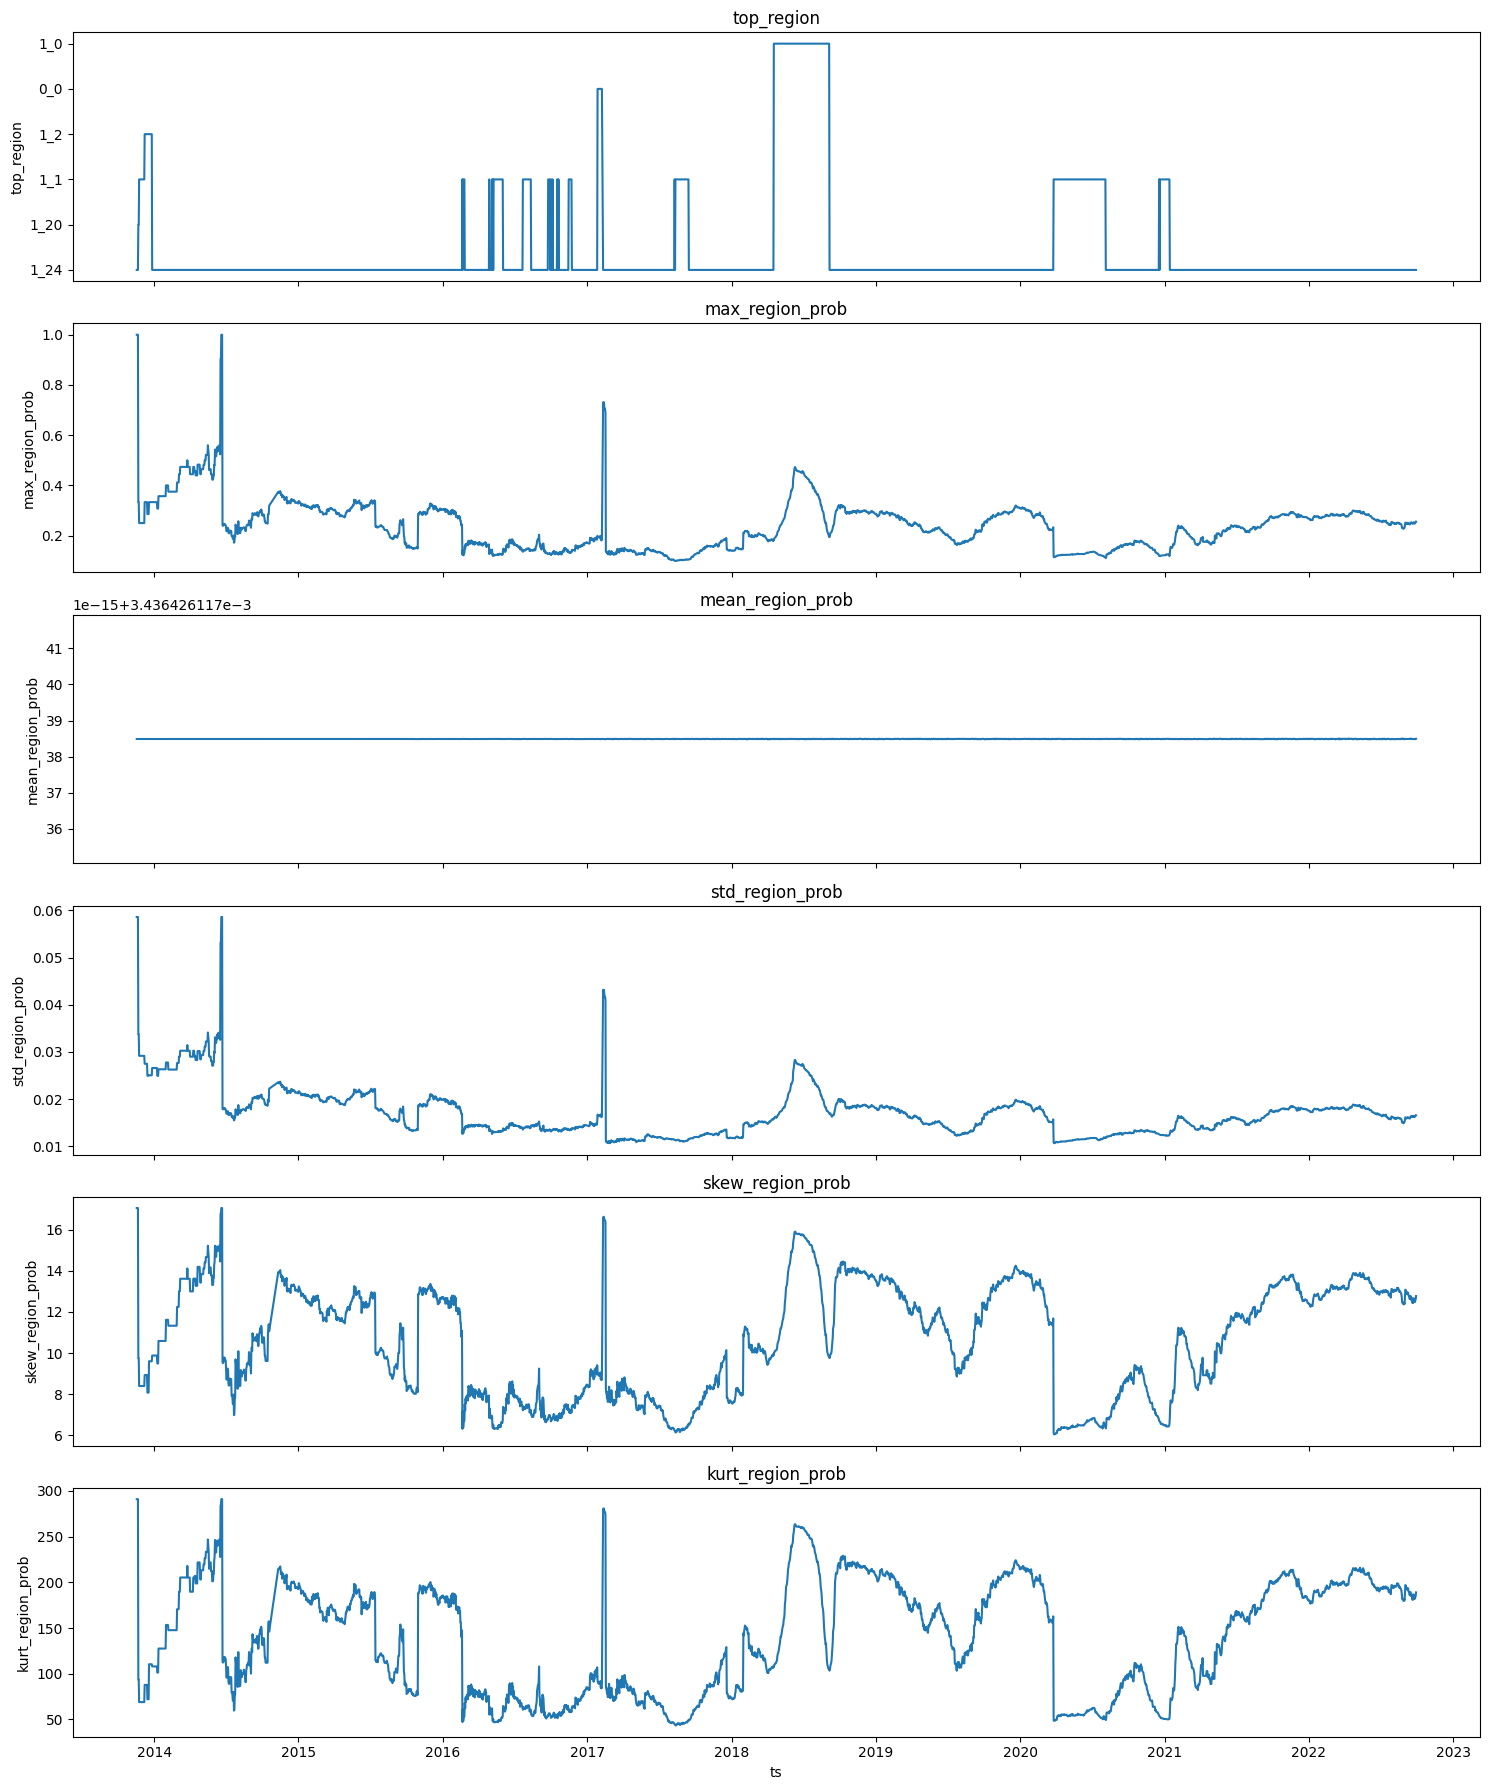

In [94]:
region_pivot = hash_attr.pivot_table(
    index=['company_id','ts'],
    columns='region',
    values='hash',
    aggfunc='nunique',
    fill_value=0,
)
# normalize to get the probability of each state on each day
region_pivot = region_pivot.div(region_pivot.sum(axis=1),axis=0)
region_dist = pd.DataFrame({
    'top_region': region_pivot.idxmax(axis=1),
    'max_region_prob': region_pivot.max(axis=1),
    'mean_region_prob': region_pivot.mean(axis=1),
    'std_region_prob': region_pivot.std(axis=1),
    'skew_region_prob': region_pivot.skew(axis=1),
    'kurt_region_prob': region_pivot.kurt(axis=1),
})
plot_feat_by_ts(region_dist)

### Correlation

In [99]:
y = daily_ret['RET']
X = pd.concat([feat,onet_dist,region_dist],axis=1)

idx = X.dropna().index.intersection(y.dropna().index)
y = y.reindex(idx)
X = X.reindex(idx)

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

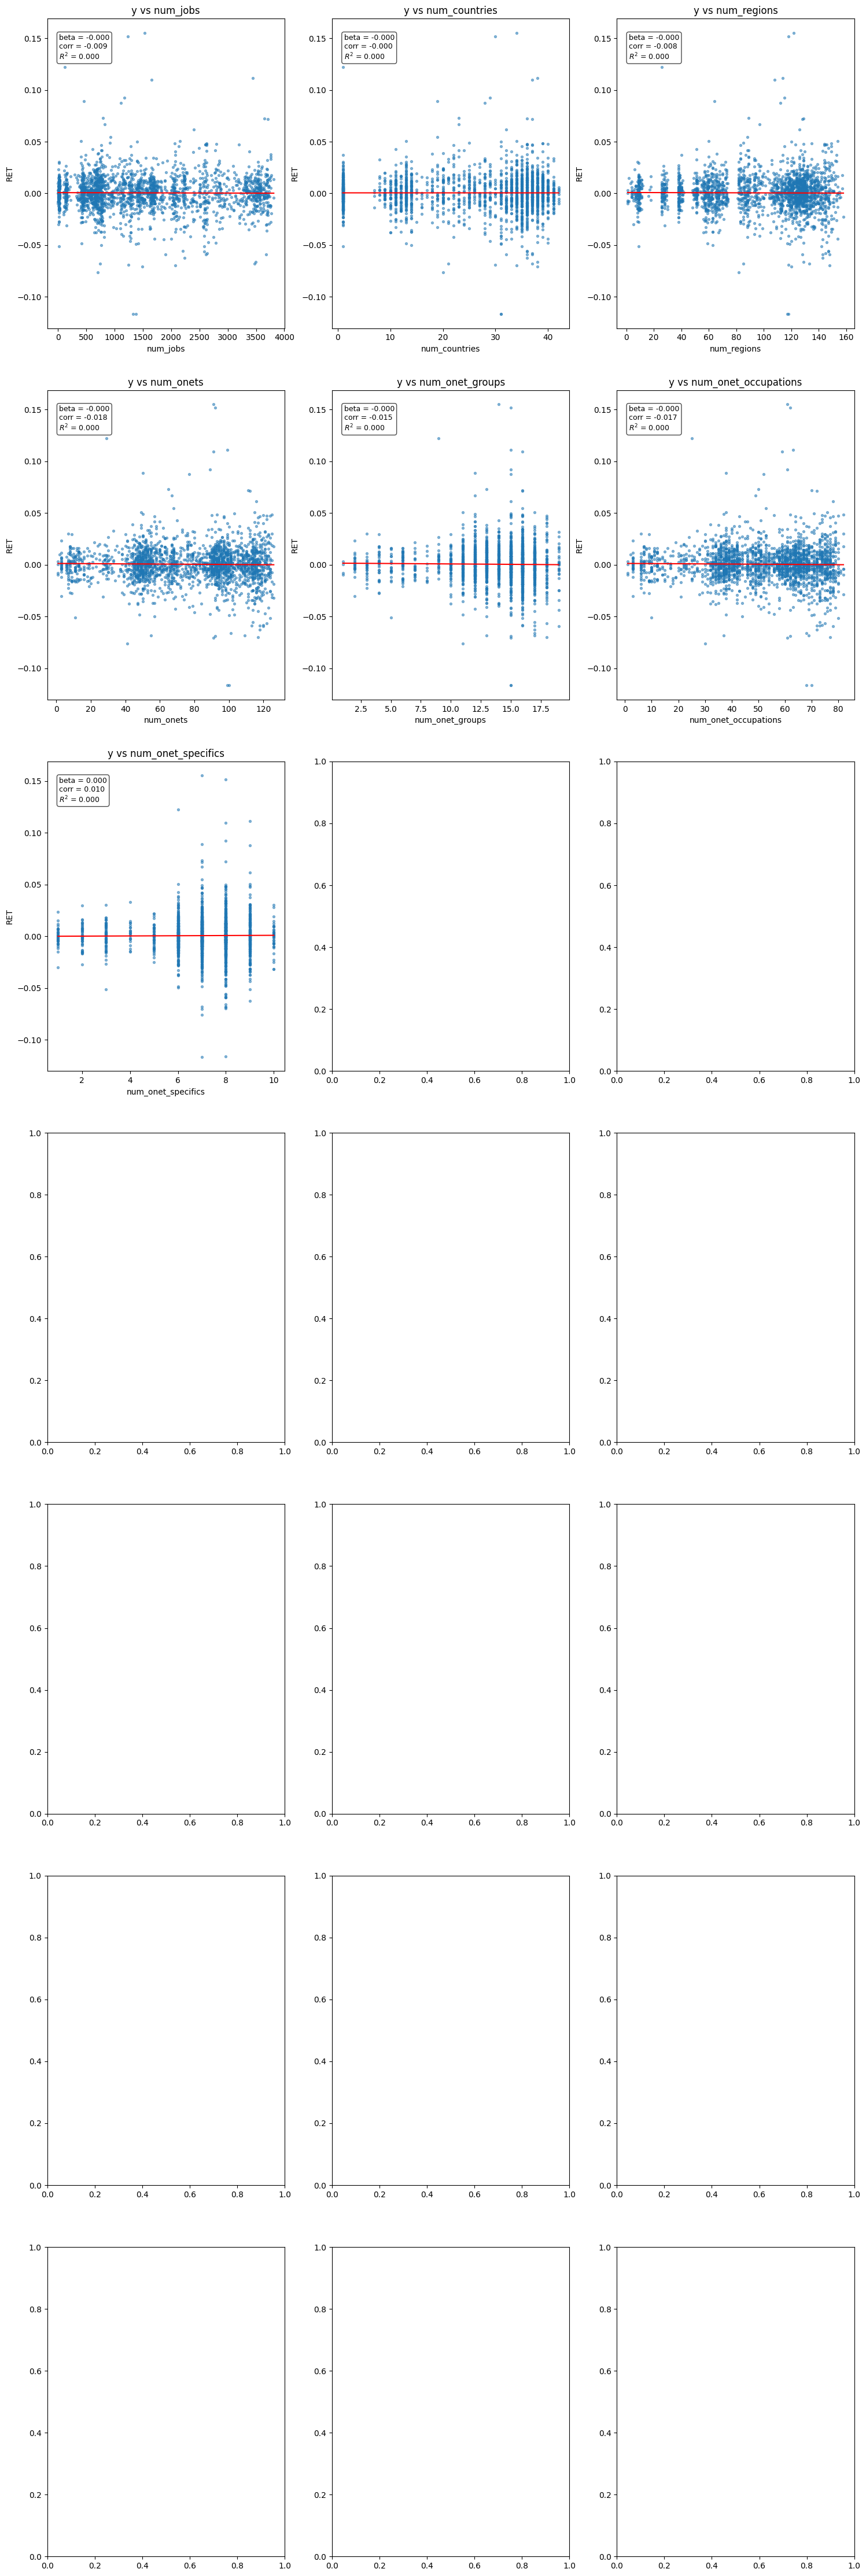

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

num_vars = X.shape[1]
fig, axes = plt.subplots(nrows=(num_vars // 3) + (num_vars % 3 > 0), ncols=3, figsize=(18, num_vars * 3))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    ax = axes[i]
    x_vec = X[col].values
    y_vec = y.values
    mask = ~np.isnan(x_vec) & ~np.isnan(y_vec)
    x = x_vec[mask].reshape(-1,1)
    y_masked = y_vec[mask]
    if len(x) == 0:
        ax.axis('off')
        continue
    # Fit regression
    lr = LinearRegression()
    lr.fit(x, y_masked)
    y_pred = lr.predict(x)
    # Stats
    beta = lr.coef_[0]
    corr = np.corrcoef(x.flatten(), y_masked)[0,1]
    r2 = lr.score(x, y_masked)
    # Scatter and trend
    ax.scatter(x, y_masked, s=8, alpha=0.5)
    xx = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
    yy = lr.predict(xx)
    ax.plot(xx, yy, color='red')
    ax.set_title(f"y vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel('RET')
    # Annotation
    textstr = f'beta = {beta:.3f}\ncorr = {corr:.3f}\n$R^2$ = {r2:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox={'boxstyle':'round', 'facecolor':'white', 'alpha':0.7})
# Remove empty subplots
for i in range(num_vars, len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()